# Step 4 — Baseline: TF-IDF + Classifiers
**Project:** SDG Mapping for PhD Thesis  
**Purpose:** Train and evaluate 4 classifiers using TF-IDF features, produce top-5 SDG predictions for MAHE corpus  
**Inputs:** `data/clean/X_train_tfidf.csv` · `data/clean/X_test_tfidf.csv` · `data/clean/y_train.csv` · `data/clean/y_test.csv` · `data/clean/mahe_tfidf.csv`  
**Outputs:** `data/results/step4_classifier_comparison.csv` · `data/results/mahe_top5_tfidf.csv`  

> Classifiers: Logistic Regression · SVM · XGBoost · Random Forest  
> Features: TF-IDF unigrams + bigrams (ngram_range=(1,2))  
> Evaluation: macro F1 · precision · recall · per-SDG breakdown


In [1]:
# Cell 1: Install dependencies 
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn tqdm


In [2]:
# Cell 2: Imports & setup 
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from tqdm.notebook import tqdm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, f1_score,
    precision_score, recall_score, accuracy_score,
    confusion_matrix
)
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

CLEAN_DIR   = Path("data/clean")
RESULTS_DIR = Path("data/results")
PLOT_DIR    = Path("data/plots")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open("data/step2_meta.json") as f:
    meta = json.load(f)
SDG_NAMES = {int(k): v for k, v in meta["sdg_names"].items()}

print("✅ Imports complete")


✅ Imports complete


In [3]:
# Cell 3: Load data 
X_train = pd.read_csv(CLEAN_DIR / "X_train_tfidf.csv")["text"].fillna("").tolist()
X_test  = pd.read_csv(CLEAN_DIR / "X_test_tfidf.csv")["text"].fillna("").tolist()
y_train = pd.read_csv(CLEAN_DIR / "y_train.csv")["sdg"].tolist()
y_test  = pd.read_csv(CLEAN_DIR / "y_test.csv")["sdg"].tolist()
mahe    = pd.read_csv(CLEAN_DIR / "mahe_tfidf.csv")["text"].fillna("").tolist()
mahe_df = pd.read_csv(CLEAN_DIR / "mahe_corpus.csv")

# SDG classes present
classes = sorted(set(y_train))
n_classes = len(classes)

print(f"X_train : {len(X_train):,} samples")
print(f"X_test  : {len(X_test):,}  samples")
print(f"MAHE    : {len(mahe):,}  documents")
print(f"Classes : {n_classes} SDGs → {classes}")


X_train : 27,204 samples
X_test  : 6,801  samples
MAHE    : 854  documents
Classes : 16 SDGs → [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]


In [4]:
# Cell 4: TF-IDF vectorizer 
# Shared vectorizer used by all classifiers
# ngram_range=(1,2) = unigrams + bigrams as per guide's hints
# max_features=50000 captures most of the 41,664 vocab from Step 3
# sublinear_tf=True reduces impact of very frequent terms

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=50000,
    sublinear_tf=True,
    min_df=2,           # ignore terms appearing in fewer than 2 docs
    max_df=0.95,        # ignore terms appearing in >95% of docs
)

X_train_vec = tfidf.fit_transform(X_train)
X_test_vec  = tfidf.transform(X_test)
X_mahe_vec  = tfidf.transform(mahe)

print(f"TF-IDF matrix shape:")
print(f"  Train : {X_train_vec.shape}")
print(f"  Test  : {X_test_vec.shape}")
print(f"  MAHE  : {X_mahe_vec.shape}")
print(f"\nVocabulary size after TF-IDF: {len(tfidf.vocabulary_):,}")
print(f"N-gram range: (1, 2) — unigrams + bigrams")

# Sample top features
feature_names = tfidf.get_feature_names_out()
print(f"\nSample features (first 20): {list(feature_names[:20])}")
print(f"Sample bigrams: {[f for f in feature_names if ' ' in f][:10]}")


TF-IDF matrix shape:
  Train : (27204, 50000)
  Test  : (6801, 50000)
  MAHE  : (854, 50000)

Vocabulary size after TF-IDF: 50,000
N-gram range: (1, 2) — unigrams + bigrams

Sample features (first 20): ['aaaa', 'aal', 'aarhus', 'aarhus convention', 'ab', 'ababa', 'ababa action', 'abandon', 'abandoned', 'abandoning', 'abandonment', 'abate', 'abatement', 'abatement cost', 'abatement option', 'abatement potential', 'abbasi', 'abbasi shavazi', 'abbasian', 'abbasian bildt']
Sample bigrams: ['aarhus convention', 'ababa action', 'abatement cost', 'abatement option', 'abatement potential', 'abbasi shavazi', 'abbasian bildt', 'ability access', 'ability attract', 'ability country']


In [5]:
# Cell 5: Define classifiers 
# All use class_weight='balanced' to handle 4.7x imbalance from Step 2

classifiers = {

    "Logistic Regression": LogisticRegression(
        C=1.0,
        max_iter=1000,
        class_weight="balanced",
        multi_class="multinomial",
        solver="lbfgs",
        random_state=42,
    ),

    "SVM": CalibratedClassifierCV(
        LinearSVC(
            C=1.0,
            max_iter=2000,
            class_weight="balanced",
            random_state=42,
        )
    ),
    # CalibratedClassifierCV wraps LinearSVC to add predict_proba()
    # which is needed for top-5 probability ranking

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),

    "XGBoost": XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric="mlogloss",
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    ),
}

print("✅ Classifiers defined:")
for name in classifiers:
    print(f"   {name}")
print()
print("All use class_weight='balanced' to handle SDG imbalance.")
print("All produce predict_proba() output for top-5 ranking.")


✅ Classifiers defined:
   Logistic Regression
   SVM
   Random Forest
   XGBoost

All use class_weight='balanced' to handle SDG imbalance.
All produce predict_proba() output for top-5 ranking.


In [6]:
# Cell 6: Train & evaluate all classifiers 
# XGBoost needs integer labels starting from 0
import numpy as np
label_map     = {sdg: idx for idx, sdg in enumerate(classes)}
label_map_inv = {idx: sdg for sdg, idx in label_map.items()}

y_train_enc = np.array([label_map[y] for y in y_train])
y_test_enc  = np.array([label_map[y] for y in y_test])

results     = {}
trained     = {}

for name, clf in classifiers.items():
    print(f"\nTraining {name}...")

    # XGBoost uses encoded labels; others use original
    if name == "XGBoost":
        clf.fit(X_train_vec, y_train_enc)
        y_pred_enc = clf.predict(X_test_vec)
        y_pred = np.array([label_map_inv[i] for i in y_pred_enc])
    else:
        clf.fit(X_train_vec, y_train)
        y_pred = clf.predict(X_test_vec)

    macro_f1  = f1_score(y_test, y_pred, average="macro",    zero_division=0)
    macro_p   = precision_score(y_test, y_pred, average="macro", zero_division=0)
    macro_r   = recall_score(y_test, y_pred, average="macro",    zero_division=0)
    accuracy  = accuracy_score(y_test, y_pred)

    results[name] = {
        "Macro F1":        round(macro_f1, 4),
        "Macro Precision": round(macro_p,  4),
        "Macro Recall":    round(macro_r,  4),
        "Accuracy":        round(accuracy, 4),
    }
    trained[name] = clf

    print(f"  Macro F1   : {macro_f1:.4f}")
    print(f"  Macro P    : {macro_p:.4f}")
    print(f"  Macro R    : {macro_r:.4f}")
    print(f"  Accuracy   : {accuracy:.4f}")

print("\n✅ All classifiers trained and evaluated")



Training Logistic Regression...
  Macro F1   : 0.8284
  Macro P    : 0.8289
  Macro R    : 0.8283
  Accuracy   : 0.8478

Training SVM...
  Macro F1   : 0.8491
  Macro P    : 0.8539
  Macro R    : 0.8458
  Accuracy   : 0.8693

Training Random Forest...
  Macro F1   : 0.7546
  Macro P    : 0.7602
  Macro R    : 0.7540
  Accuracy   : 0.7828

Training XGBoost...
  Macro F1   : 0.8036
  Macro P    : 0.8128
  Macro R    : 0.7986
  Accuracy   : 0.8302

✅ All classifiers trained and evaluated


In [7]:
# Cell 7: Comparison table 
df_results = pd.DataFrame(results).T.sort_values("Macro F1", ascending=False)
df_results.index.name = "Classifier"

print("=" * 60)
print("  CLASSIFIER COMPARISON — TF-IDF Features")
print("=" * 60)
print(df_results.to_string())
print()

best_clf_name = df_results.index[0]
best_f1       = df_results.iloc[0]["Macro F1"]
print(f"Best classifier : {best_clf_name} (Macro F1 = {best_f1:.4f})")

# Save comparison
df_results.to_csv(RESULTS_DIR / "step4_classifier_comparison.csv")
print(f"\n💾 Saved: data/results/step4_classifier_comparison.csv")


  CLASSIFIER COMPARISON — TF-IDF Features
                     Macro F1  Macro Precision  Macro Recall  Accuracy
Classifier                                                            
SVM                    0.8491           0.8539        0.8458    0.8693
Logistic Regression    0.8284           0.8289        0.8283    0.8478
XGBoost                0.8036           0.8128        0.7986    0.8302
Random Forest          0.7546           0.7602        0.7540    0.7828

Best classifier : SVM (Macro F1 = 0.8491)

💾 Saved: data/results/step4_classifier_comparison.csv


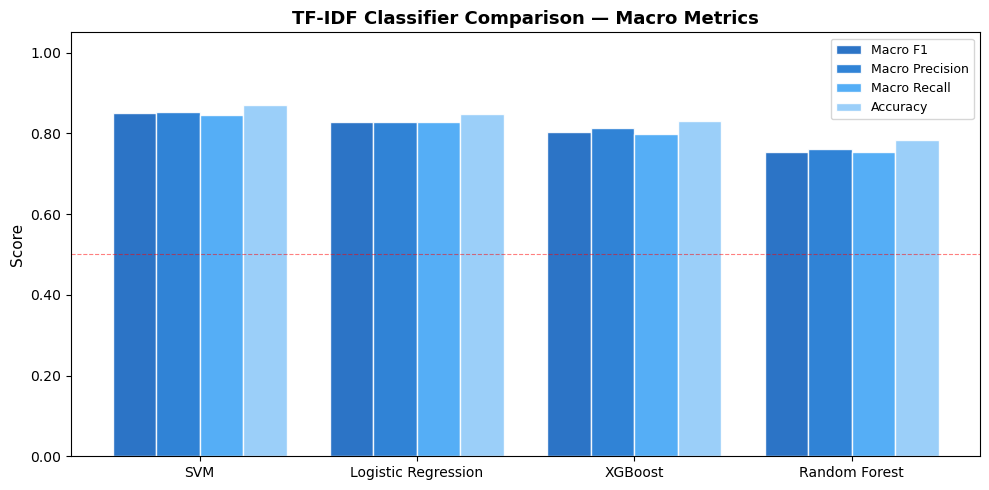

✅ Comparison chart saved


In [8]:
# Cell 8: Comparison bar chart 
fig, ax = plt.subplots(figsize=(10, 5))

metrics  = ["Macro F1", "Macro Precision", "Macro Recall", "Accuracy"]
x        = np.arange(len(df_results))
width    = 0.2
colors   = ["#1565C0", "#1976D2", "#42A5F5", "#90CAF9"]

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = ax.bar(x + i * width, df_results[metric], width,
                  label=metric, color=color, edgecolor="white", alpha=0.9)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(df_results.index, fontsize=10)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("TF-IDF Classifier Comparison — Macro Metrics", fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.set_ylim(0, 1.05)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}"))
ax.axhline(0.5, color="red", linestyle="--", linewidth=0.8, alpha=0.5, label="0.5 baseline")
plt.tight_layout()
plt.savefig(PLOT_DIR / "06_tfidf_classifier_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Comparison chart saved")


In [9]:
# Cell 9: Per-SDG breakdown for best classifier 
best_clf = trained[best_clf_name]

if best_clf_name == "XGBoost":
    y_pred_best_enc = best_clf.predict(X_test_vec)
    y_pred_best = np.array([label_map_inv[i] for i in y_pred_best_enc])
else:
    y_pred_best = best_clf.predict(X_test_vec)

report = classification_report(
    y_test, y_pred_best,
    labels=classes,
    target_names=[f"SDG {c} — {SDG_NAMES.get(c,'')[:25]}" for c in classes],
    output_dict=True,
    zero_division=0
)

df_report = pd.DataFrame(report).T
df_report = df_report[df_report.index.str.startswith("SDG")]
df_report = df_report[["precision", "recall", "f1-score", "support"]]
df_report.columns = ["Precision", "Recall", "F1", "Support"]

print(f"Per-SDG Performance — {best_clf_name}")
print("=" * 70)
print(df_report.round(3).to_string())
print()

# Identify weak SDGs
weak = df_report[df_report["F1"] < 0.5]
if len(weak) > 0:
    print(f"\n⚠ SDGs with F1 < 0.5 (may need more training data or SMOTE):")
    for idx in weak.index:
        print(f"  {idx} : F1 = {weak.loc[idx,'F1']:.3f}")

df_report.to_csv(RESULTS_DIR / "step4_per_sdg_report.csv")
print(f"\n💾 Saved: data/results/step4_per_sdg_report.csv")


Per-SDG Performance — SVM
                                    Precision  Recall     F1  Support
SDG 1 — No Poverty                      0.831   0.781  0.805    397.0
SDG 2 — Zero Hunger                     0.880   0.888  0.884    322.0
SDG 3 — Good Health and Well-Bein       0.908   0.933  0.920    476.0
SDG 4 — Quality Education               0.915   0.932  0.924    616.0
SDG 5 — Gender Equality                 0.881   0.932  0.906    651.0
SDG 6 — Clean Water and Sanitatio       0.905   0.877  0.891    415.0
SDG 7 — Affordable and Clean Ener       0.855   0.892  0.873    510.0
SDG 8 — Decent Work and Economic        0.687   0.569  0.622    262.0
SDG 9 — Industry, Innovation and        0.818   0.843  0.830    470.0
SDG 10 — Reduced Inequalities           0.730   0.719  0.725    342.0
SDG 11 — Sustainable Cities and Co      0.810   0.848  0.829    388.0
SDG 12 — Responsible Consumption a      0.822   0.733  0.775    176.0
SDG 13 — Climate Action                 0.830   0.805  0.817    

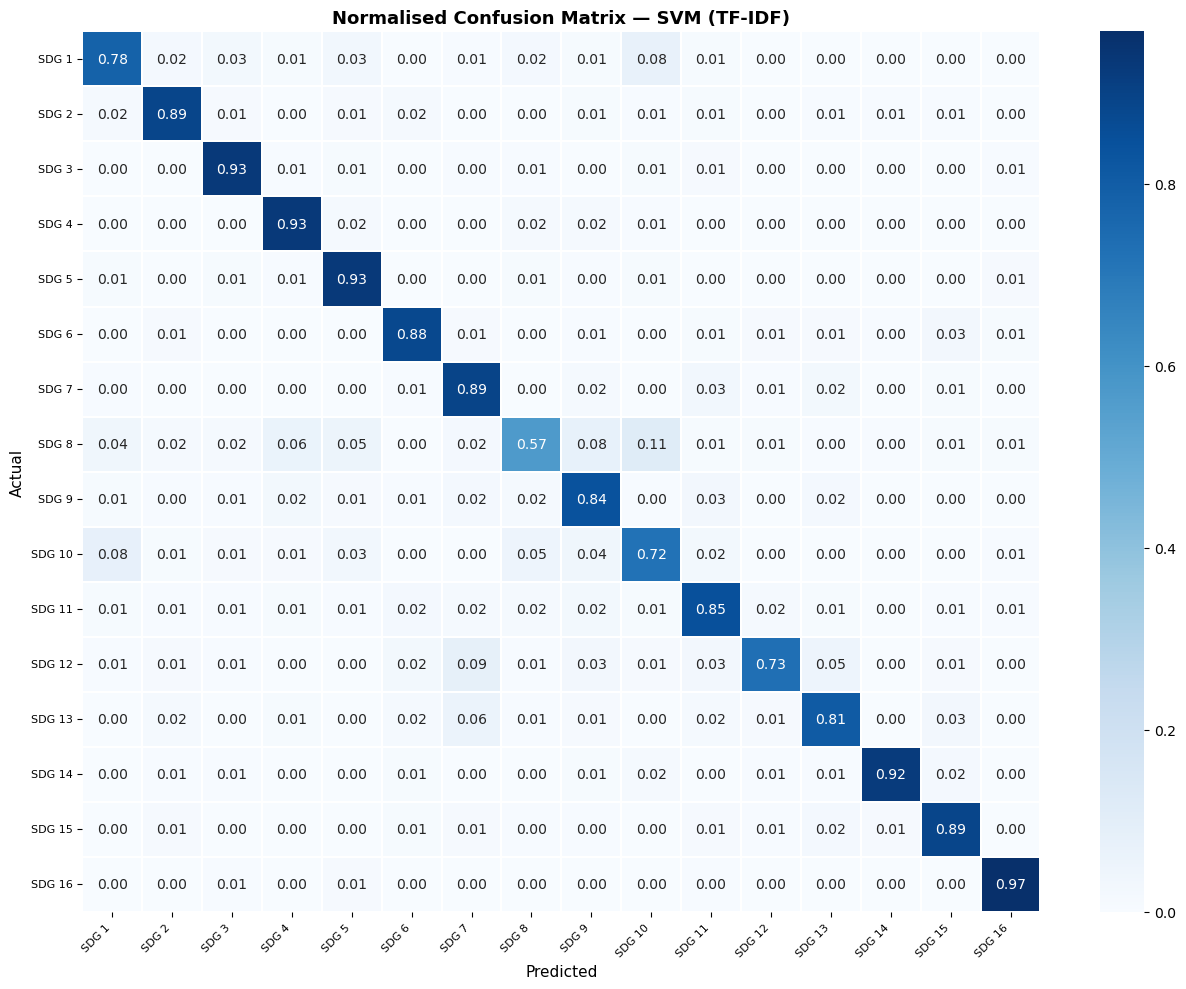

✅ Confusion matrix saved

Diagonal values = correct prediction rate per SDG
Off-diagonal values = confusion between SDGs


In [10]:
# Cell 10: Confusion matrix heatmap 
cm = confusion_matrix(y_test, y_pred_best, labels=classes)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    cm_norm,
    annot=True, fmt=".2f",
    cmap="Blues",
    xticklabels=[f"SDG {c}" for c in classes],
    yticklabels=[f"SDG {c}" for c in classes],
    linewidths=0.3, linecolor="white",
    ax=ax
)
ax.set_xlabel("Predicted", fontsize=11)
ax.set_ylabel("Actual", fontsize=11)
ax.set_title(f"Normalised Confusion Matrix — {best_clf_name} (TF-IDF)",
             fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(PLOT_DIR / "07_confusion_matrix_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Confusion matrix saved")
print()
print("Diagonal values = correct prediction rate per SDG")
print("Off-diagonal values = confusion between SDGs")


In [11]:
# Cell 11: Top-5 SDG predictions for MAHE corpus 
print(f"Generating top-5 SDG predictions for {len(mahe):,} MAHE articles...")
print(f"Using: {best_clf_name} with TF-IDF features")
print()

# Get probability scores
if best_clf_name == "XGBoost":
    proba = best_clf.predict_proba(X_mahe_vec)
    clf_classes = [label_map_inv[i] for i in range(len(classes))]
else:
    proba = best_clf.predict_proba(X_mahe_vec)
    clf_classes = list(best_clf.classes_)

# Build top-5 results
mahe_results = []
for i in range(len(mahe)):
    # Get probabilities for this document
    doc_proba = proba[i]

    # Sort by probability descending
    sorted_idx = np.argsort(doc_proba)[::-1]

    # Top 5 SDGs with scores
    top5_sdgs   = [int(clf_classes[j]) for j in sorted_idx[:5]]
    top5_scores = [round(float(doc_proba[j]), 4) for j in sorted_idx[:5]]
    top5_names  = [SDG_NAMES.get(s, f"SDG {s}") for s in top5_sdgs]

    # Softmax of top-5 scores for normalised ranking
    top5_arr    = np.array(top5_scores)
    exp_scores  = np.exp(top5_arr - top5_arr.max())
    softmax     = (exp_scores / exp_scores.sum()).round(4)

    mahe_results.append({
        "Title":            mahe_df.iloc[i]["title"] if "title" in mahe_df.columns else mahe_df.iloc[i]["text"][:80],
        "Rank1_SDG":        f"SDG {top5_sdgs[0]}",
        "Rank1_Name":       top5_names[0],
        "Rank1_Score":      top5_scores[0],
        "Rank2_SDG":        f"SDG {top5_sdgs[1]}",
        "Rank2_Name":       top5_names[1],
        "Rank2_Score":      top5_scores[1],
        "Rank3_SDG":        f"SDG {top5_sdgs[2]}",
        "Rank3_Name":       top5_names[2],
        "Rank3_Score":      top5_scores[2],
        "Rank4_SDG":        f"SDG {top5_sdgs[3]}",
        "Rank4_Name":       top5_names[3],
        "Rank4_Score":      top5_scores[3],
        "Rank5_SDG":        f"SDG {top5_sdgs[4]}",
        "Rank5_Name":       top5_names[4],
        "Rank5_Score":      top5_scores[4],
        "Top5_SDGs":        ", ".join([f"SDG {s}" for s in top5_sdgs]),
        "Softmax_Scores":   ", ".join([str(s) for s in softmax]),
        "All_Probabilities": ", ".join([f"SDG {int(clf_classes[j])}:{doc_proba[j]:.4f}"
                                        for j in sorted_idx])
    })

df_mahe_results = pd.DataFrame(mahe_results)
df_mahe_results.to_csv(RESULTS_DIR / "mahe_top5_tfidf.csv", index=False, encoding="utf-8-sig")

print(f"✅ Top-5 predictions generated for all {len(df_mahe_results):,} MAHE articles")
print(f"💾 Saved: data/results/mahe_top5_tfidf.csv")
print()
print("Sample predictions:")
print(df_mahe_results[["Title","Rank1_SDG","Rank1_Name","Rank1_Score",
                         "Rank2_SDG","Rank2_Name","Top5_SDGs"]].head(5).to_string())


Generating top-5 SDG predictions for 854 MAHE articles...
Using: SVM with TF-IDF features

✅ Top-5 predictions generated for all 854 MAHE articles
💾 Saved: data/results/mahe_top5_tfidf.csv

Sample predictions:
                                                                                                                 Title Rank1_SDG                               Rank1_Name  Rank1_Score Rank2_SDG                              Rank2_Name                              Top5_SDGs
0                 Analytical and bioanalytical HPLC method for simultaneous estimation of 5-fluorouracil and sonidegib     SDG 6               Clean Water and Sanitation       0.3280    SDG 12  Responsible Consumption and Production     SDG 6, SDG 12, SDG 9, SDG 1, SDG 4
1                           ‘Solving’ as a key course learning outcome (CLO) in postgraduate (PG) management education     SDG 4                        Quality Education       0.9148    SDG 16  Peace, Justice and Strong Institutions   SDG 4, SDG 

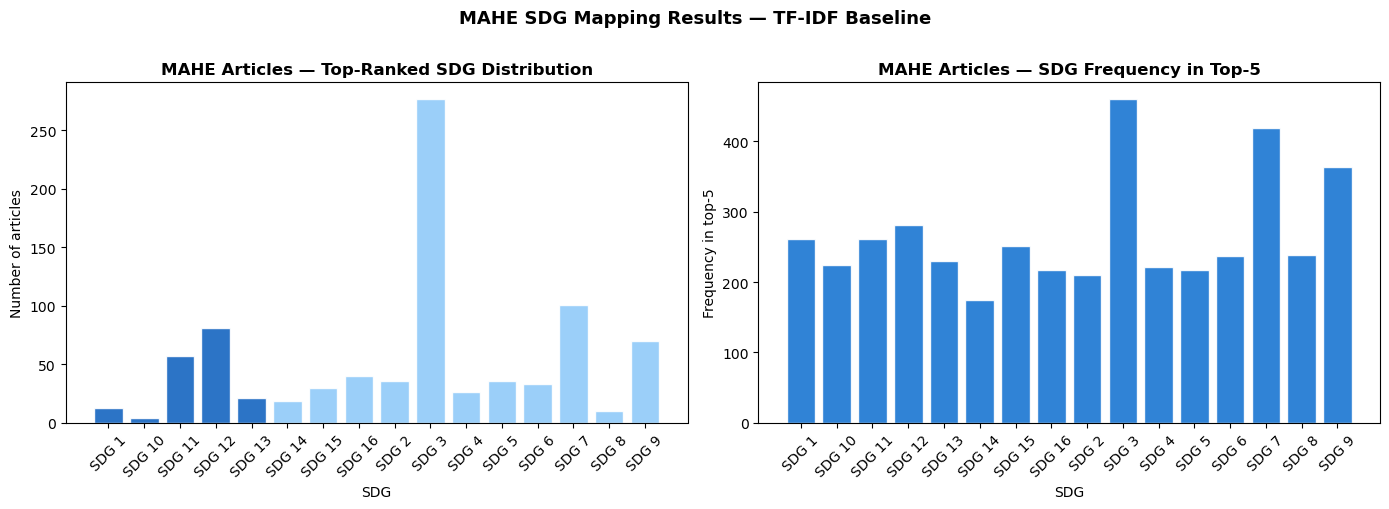

Top 5 most common Rank-1 SDGs in MAHE corpus:
  SDG 1 — No Poverty                                    : 13 articles
  SDG 10 — Reduced Inequalities                          : 4 articles
  SDG 11 — Sustainable Cities and Communities            : 57 articles
  SDG 12 — Responsible Consumption and Production        : 81 articles
  SDG 13 — Climate Action                                : 21 articles


In [12]:
# Cell 12: MAHE SDG distribution analysis 
# What SDGs does MAHE research map to most?

rank1_dist = df_mahe_results["Rank1_SDG"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rank 1 distribution
colors = ["#1565C0" if i < 5 else "#90CAF9" for i in range(len(rank1_dist))]
axes[0].bar(rank1_dist.index, rank1_dist.values,
            color=colors, edgecolor="white", alpha=0.9)
axes[0].set_title("MAHE Articles — Top-Ranked SDG Distribution",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("SDG", fontsize=10)
axes[0].set_ylabel("Number of articles", fontsize=10)
axes[0].tick_params(axis="x", rotation=45)

# Top-5 cumulative (how often each SDG appears in any top-5)
all_top5 = []
for sdgs in df_mahe_results["Top5_SDGs"]:
    all_top5.extend([s.strip() for s in sdgs.split(",")])
top5_dist = pd.Series(all_top5).value_counts().sort_index()

axes[1].bar(top5_dist.index, top5_dist.values,
            color="#1976D2", edgecolor="white", alpha=0.9)
axes[1].set_title("MAHE Articles — SDG Frequency in Top-5",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("SDG", fontsize=10)
axes[1].set_ylabel("Frequency in top-5", fontsize=10)
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("MAHE SDG Mapping Results — TF-IDF Baseline",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(PLOT_DIR / "08_mahe_sdg_distribution_tfidf.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 most common Rank-1 SDGs in MAHE corpus:")
for sdg, count in rank1_dist.head(5).items():
    sdg_num = int(sdg.split()[1])
    print(f"  {sdg} — {SDG_NAMES.get(sdg_num,''):<45} : {count:,} articles")


In [13]:
# Cell 13: Step 4 summary 
print("=" * 62)
print("  STEP 4 — TF-IDF BASELINE SUMMARY")
print("=" * 62)
print()
print("  Feature extraction:")
print("    TF-IDF, ngram_range=(1,2), max_features=50,000")
print("    sublinear_tf=True, min_df=2, max_df=0.95")
print()
print("  Classifier results (Macro F1):")
for clf_name, row in df_results.iterrows():
    marker = " ← best" if clf_name == best_clf_name else ""
    print(f"    {clf_name:<22} : {row['Macro F1']:.4f}{marker}")
print()
print(f"  Best classifier : {best_clf_name}")
print(f"  Best Macro F1   : {best_f1:.4f}")
print()
print(f"  MAHE predictions: top-5 SDGs per article")
print(f"    File: data/results/mahe_top5_tfidf.csv")
print()
print("  Next steps:")
print("    Step 5 — replace TF-IDF with Word2Vec/GloVe embeddings")
print("    Expect improvement especially for semantically similar SDGs")
print()
print("✅ Step 4 complete → next: step5_embeddings.ipynb")
print("=" * 62)


  STEP 4 — TF-IDF BASELINE SUMMARY

  Feature extraction:
    TF-IDF, ngram_range=(1,2), max_features=50,000
    sublinear_tf=True, min_df=2, max_df=0.95

  Classifier results (Macro F1):
    SVM                    : 0.8491 ← best
    Logistic Regression    : 0.8284
    XGBoost                : 0.8036
    Random Forest          : 0.7546

  Best classifier : SVM
  Best Macro F1   : 0.8491

  MAHE predictions: top-5 SDGs per article
    File: data/results/mahe_top5_tfidf.csv

  Next steps:
    Step 5 — replace TF-IDF with Word2Vec/GloVe embeddings
    Expect improvement especially for semantically similar SDGs

✅ Step 4 complete → next: step5_embeddings.ipynb
